In [1]:
import os
from functools import partial
import pandas as pd
import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "highest")
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

## Ablation: Optimizer

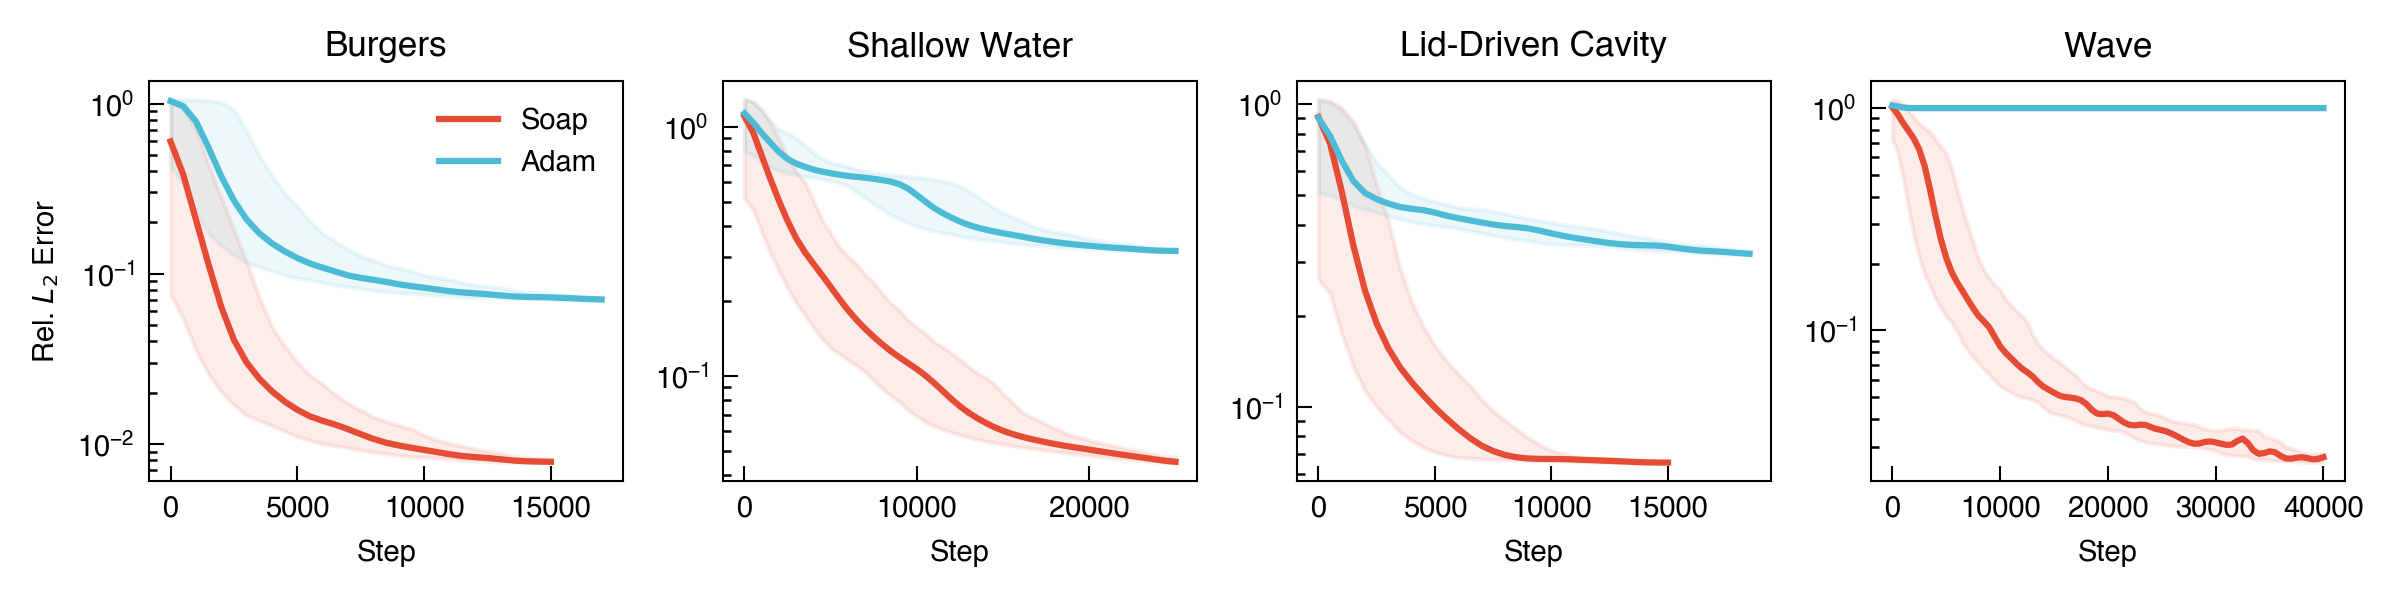

In [2]:
datasets = {
    "Burgers": [
        "training_logs/burgers/run-burgers_cvit_sota-nofilm-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_cvit_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Shallow Water": [
        "training_logs/swe/run-swe_cvit_SOTA-0217-tag-eval_l2_error.csv",
        "training_logs/swe/run-swe_cvit_ablation_adam-tag-eval_l2_error.csv",
    ],
    "Lid-Driven Cavity": [
        "training_logs/ldc/run-ldc_cvit_SOTA-0218-decdepth4-tag-eval_l2_error.csv",
        "training_logs/ldc/run-ldc_cvit_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Wave": [
        "training_logs/wave/run-wave_cvit_SOTA-decdim384-decdepth4-decheads12-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_cvit_ablation_adam-tag-eval_l2_error.csv",
    ]
}

tags = ["Soap", "Adam"]

from models.utils import smooth_loss_log_gaussian
fig, axes = plt.subplots(1, 4, figsize=(8, 2),)
axes = axes.flatten()
for idx, (name, paths) in enumerate(datasets.items()):
    ax = axes[idx]
    for j, (path, tag) in enumerate(zip(paths, tags)):
        df = pd.read_csv(path)
        val = df["Value"].values
        step = df["Step"].values
        mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.2, n_boot=1000)
        ax.fill_between(step, lower, upper, color=f"C{j}", alpha=0.1,)
        ax.plot(step, mean, label=tag, color=f"C{j}")

    ax.set(xlabel="Step", title=name,
           yscale="log")
    if idx == 0:
        ax.legend()
        ax.set(ylabel="Rel. $L_2$ Error")
        
fig.tight_layout()
# fig.savefig("./figures/ablation_optimizer.pdf", bbox_inches="tight", pad_inches=0.01)
# fig.savefig("./figures/ablation_optimizer.png", bbox_inches="tight", pad_inches=0.01, dpi=300)

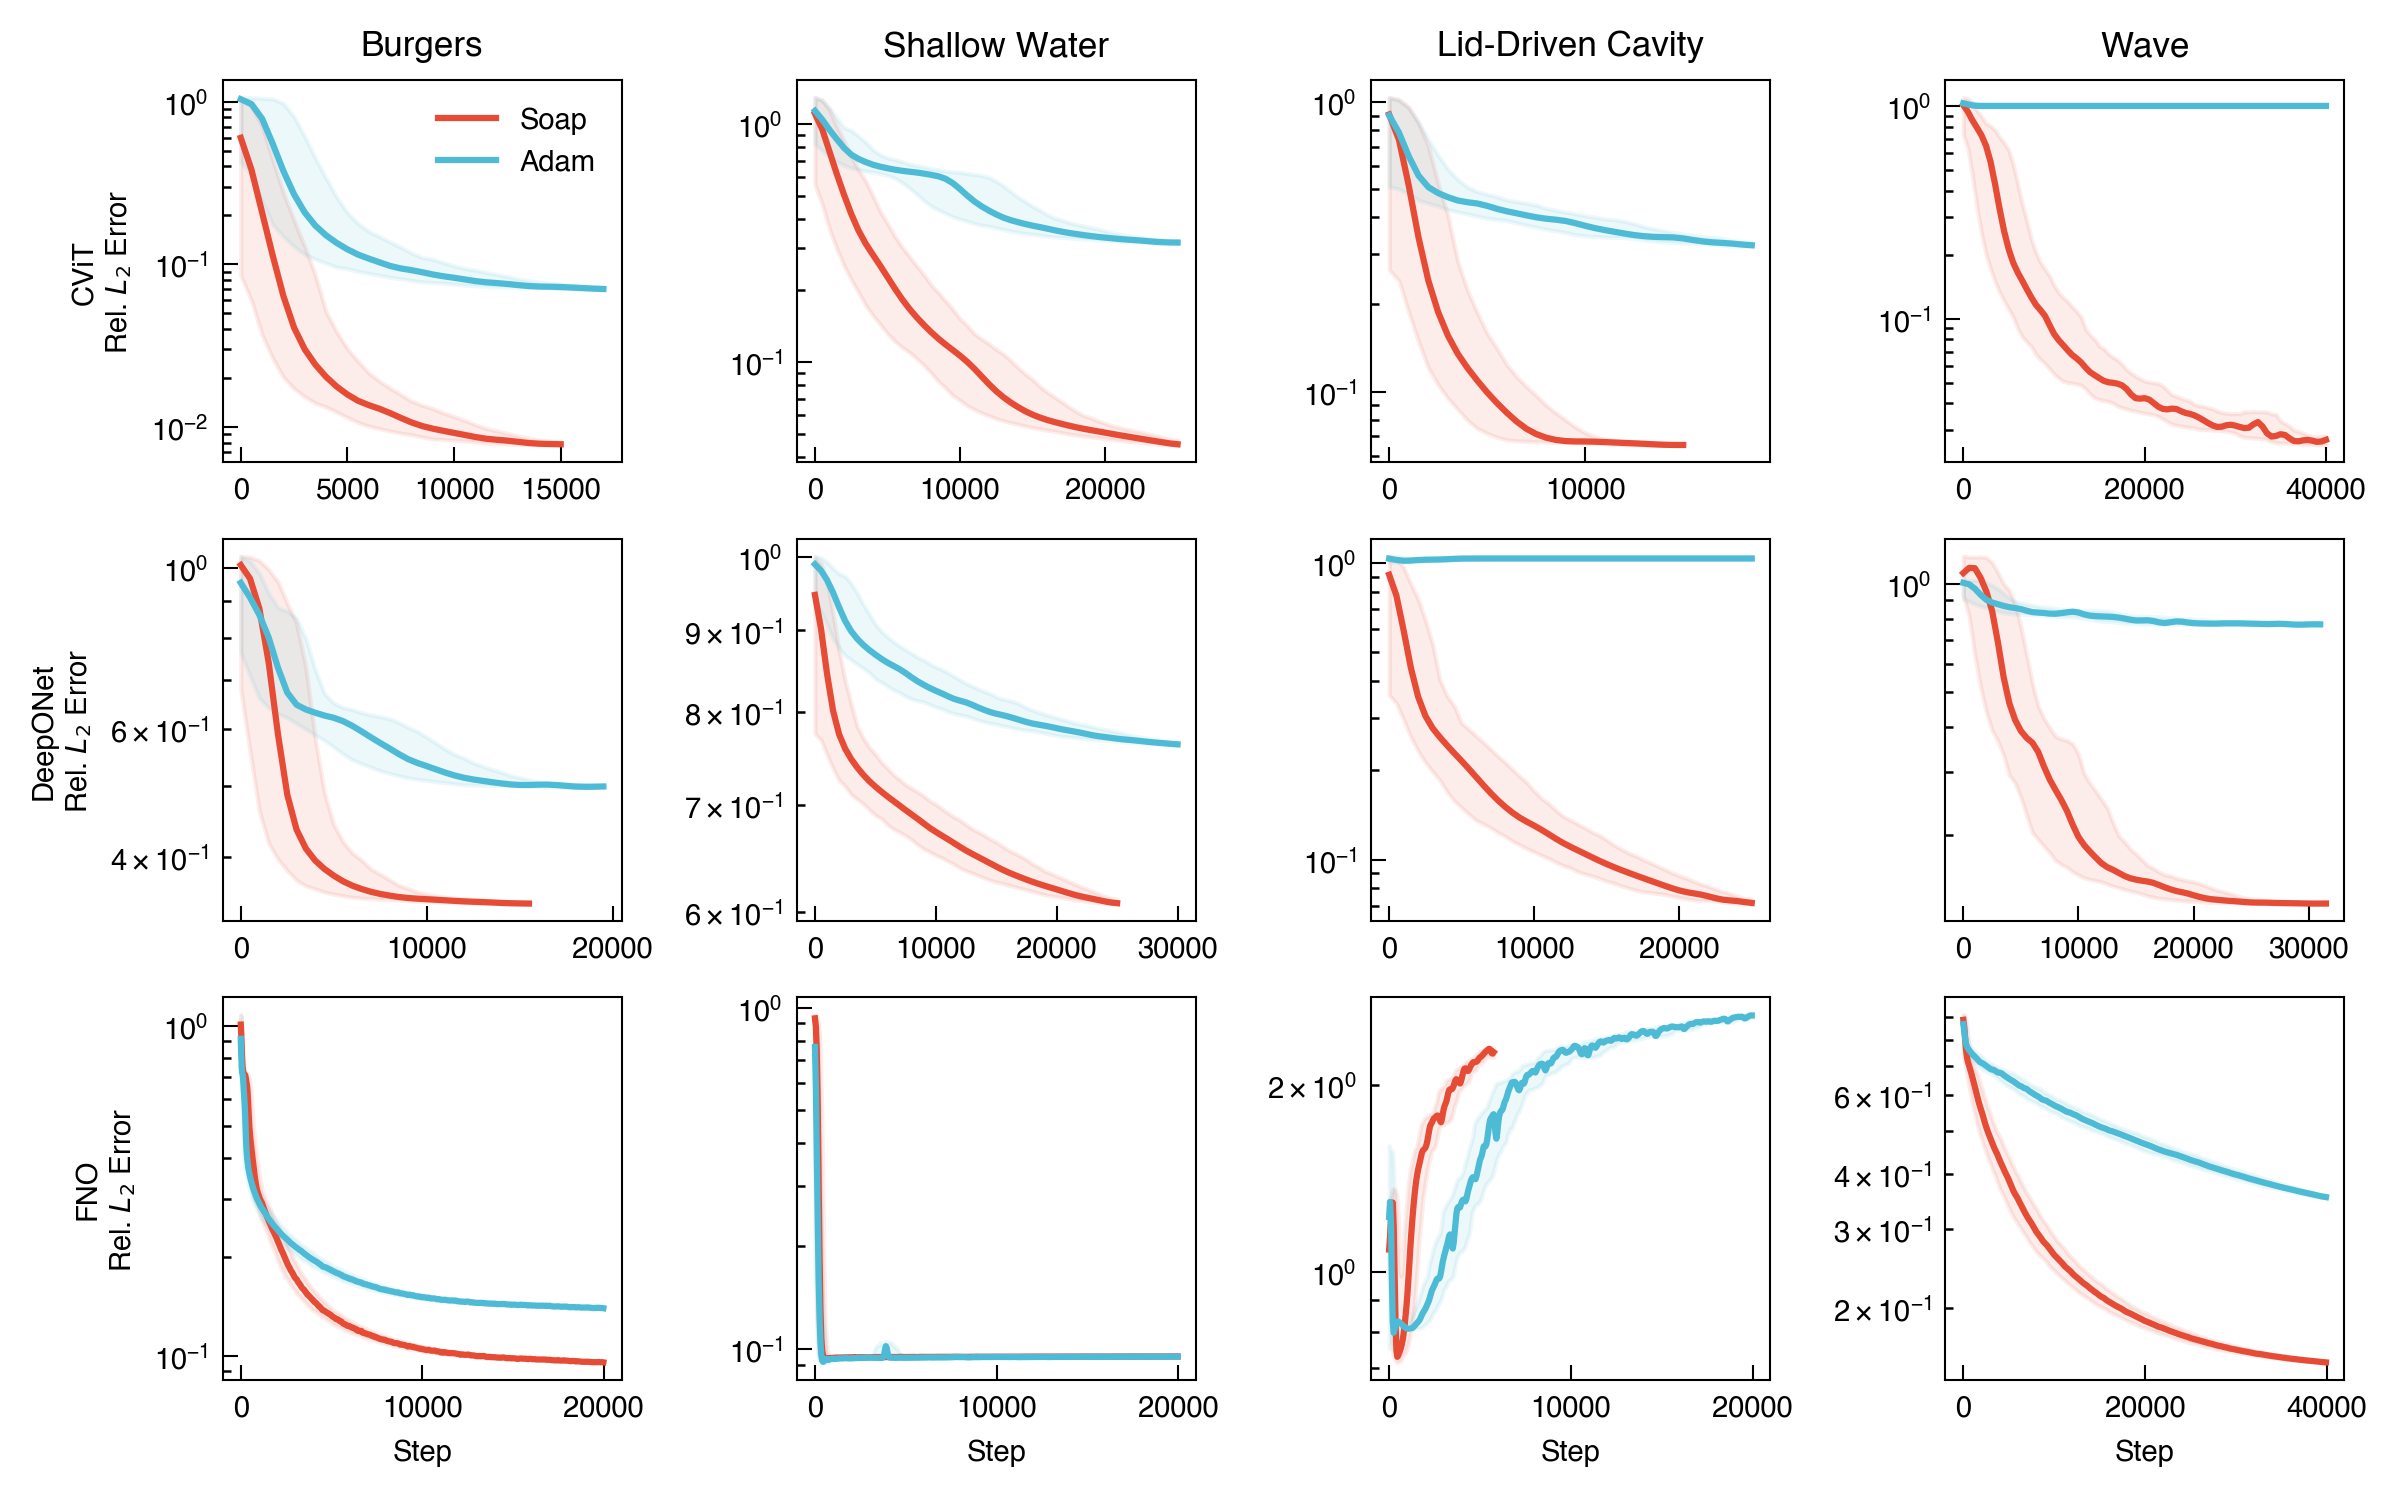

In [3]:
cvit_ret = {
    "Burgers": [
        "training_logs/burgers/run-burgers_cvit_sota-nofilm-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_cvit_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Shallow Water": [
        "training_logs/swe/run-swe_cvit_SOTA-0217-tag-eval_l2_error.csv",
        "training_logs/swe/run-swe_cvit_ablation_adam-tag-eval_l2_error.csv",
    ],
    "Lid-Driven Cavity": [
        "training_logs/ldc/run-ldc_cvit_SOTA-0218-decdepth4-tag-eval_l2_error.csv",
        "training_logs/ldc/run-ldc_cvit_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Wave": [
        "training_logs/wave/run-wave_cvit_SOTA-decdim384-decdepth4-decheads12-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_cvit_ablation_adam-tag-eval_l2_error.csv",
    ]
}
deeponet_ret = {
    "Burgers": [
        "training_logs/burgers/run-burgers_deeponet_baseline-0219-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_deeponet_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Shallow Water": [
        "training_logs/swe/run-swe_deeponet_baseline-tag-eval_l2_error.csv",
        "training_logs/swe/run-swe_deeponet_adam-tag-eval_l2_error.csv"
    ],
    "Lid-Driven Cavity": [
        "training_logs/ldc/run-ldc_deeponet_baseline-tag-eval_l2_error.csv",
        "training_logs/ldc/run-ldc_deeponet_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Wave": [
        "training_logs/wave/run-wave_deeponet_baseline-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_deeponet_ablation_adam-tag-eval_l2_error.csv",
    ]
}
fno_ret = {
    "Burgers": [
        "training_logs/burgers/run-burgers_fno_soap-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_fno_ablatioin_adam-tag-eval_l2_error.csv"
    ],
    "Shallow Water": [
        "training_logs/swe/run-swe_fno_soap-tag-eval_l2_error.csv",
        "training_logs/swe/run-swe_fno_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Lid-Driven Cavity": [
        "training_logs/ldc/run-ldc_fno_soap2-tag-eval_l2_error.csv",
        "training_logs/ldc/run-ldc_fno_ablation_adam-tag-eval_l2_error.csv"
    ],
    "Wave": [
        "training_logs/wave/run-wave_fno_soap-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_fno_ablation_adam-tag-eval_l2_error.csv"
    ]
}

tags = ["Soap", "Adam"]
model_names = ["CViT", "DeepONet", "FNO"]


from models.utils import smooth_loss_log_gaussian
fig, axes = plt.subplots(3, 4, figsize=(8, 5),)
# axes = axes.flatten()
for model_id, dataset in enumerate([cvit_ret, deeponet_ret, fno_ret]):

    for example_idx, (name, paths) in enumerate(dataset.items()):
        ax = axes[model_id, example_idx]
        
        if example_idx == 0:
            ax.set_ylabel(f"{model_names[model_id]}\nRel. $L_2$ Error")
            # ax.text(-0.2, 0.5, model_names[model_id], 
            #         va="center", ha="center", rotation=90, transform=ax.transAxes)

        if model_id == 0:
            ax.set_title(name)
        if model_id == 2:
            ax.set_xlabel("Step")
            
        if len(paths) == 0:
            continue
            
        for j, (path, tag) in enumerate(zip(paths, tags)):
            df = pd.read_csv(path)
            val = df["Value"].values
            step = df["Step"].values
            mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.2, n_boot=1000)
            ax.fill_between(step, lower, upper, color=f"C{j}", alpha=0.1,)
            ax.plot(step, mean, label=tag, color=f"C{j}")
        ax.set_yscale("log")
        
        if model_id == 0 and example_idx == 0:
            ax.legend()
fig.tight_layout()


## Ablation: FiLM-conditioning

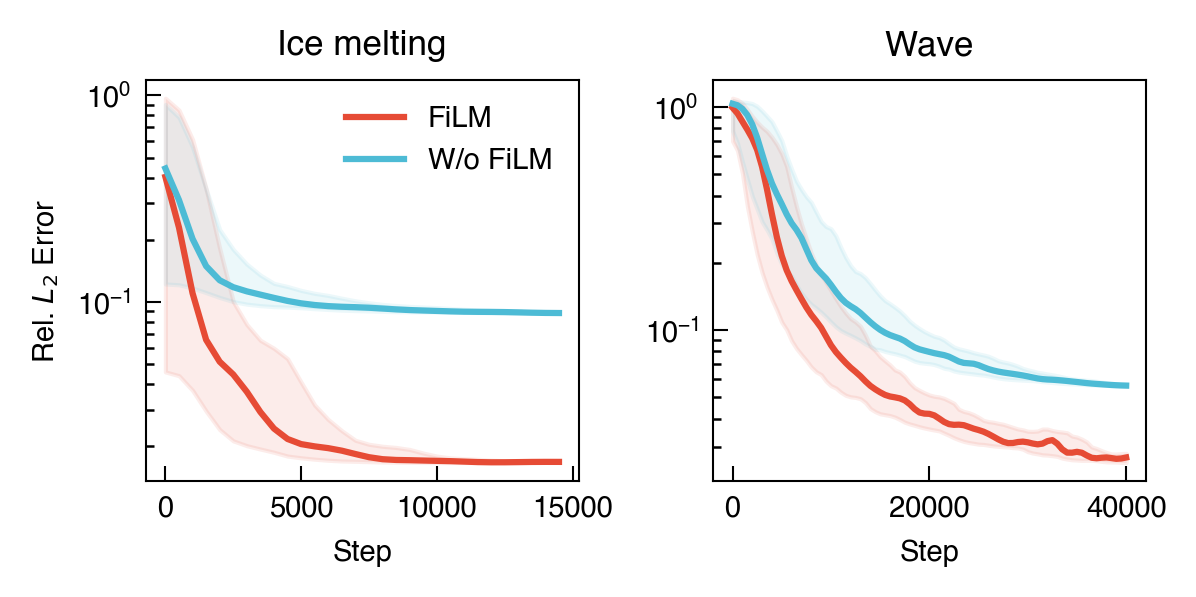

In [4]:
datasets = {
    "Ice melting": [
        "training_logs/ice_melting/run-ice_melting_ellipse_cvit_sota-0121-tag-eval_l2_error.csv",
        "training_logs/ice_melting/run-ice_melting_ellipse_cvit_no-film-tag-eval_l2_error.csv"
    ],
    "Wave": [
        "training_logs/wave/run-wave_cvit_SOTA-decdim384-decdepth4-decheads12-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_cvit_SOTA-nofilm-tag-eval_l2_error.csv"
    ]
}

tags = ["FiLM", "W/o FiLM"]
fig, axes = plt.subplots(1, 2, figsize=(4, 2),)
axes = axes.flatten()
for idx, (name, paths) in enumerate(datasets.items()):
    ax = axes[idx]
    for j, (path, tag) in enumerate(zip(paths, tags)):
        df = pd.read_csv(path)
        val = df["Value"].values
        step = df["Step"].values
        mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.4, n_boot=1000)
        ax.fill_between(step, lower, upper, color=f"C{j}", alpha=0.1,)
        ax.plot(step, mean, label=tag, color=f"C{j}")

    ax.set(xlabel="Step", title=name,
           yscale="log")
    if idx == 0:
        ax.legend()
        ax.set(ylabel="Rel. $L_2$ Error")
        
fig.tight_layout()
# fig.savefig("./figures/ablation_film.pdf", bbox_inches="tight", pad_inches=0.01)
# fig.savefig("./figures/ablation_film.png", bbox_inches="tight", pad_inches=0.01, dpi=300)

## Ablation: Causal and GranNorm

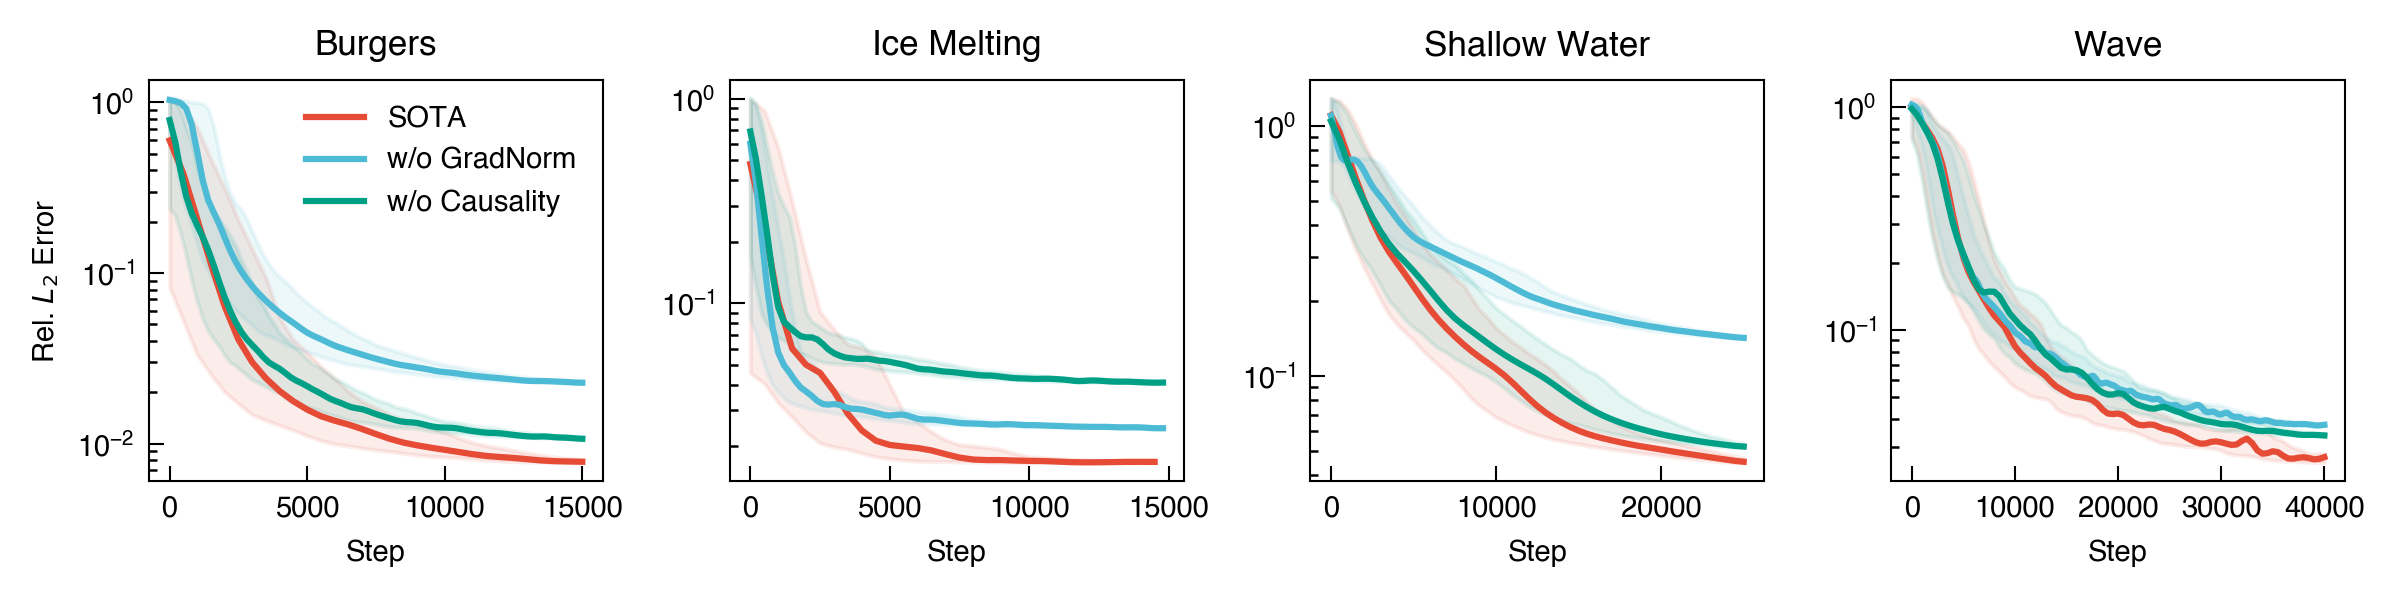

In [5]:
cvit_ret = {
    "Burgers": [
        "training_logs/burgers/run-burgers_cvit_sota-nofilm-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_cvit_ablation_no_gradnorm_20260320-115609-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_cvit_ablation_no_causality_20260320-215320-tag-eval_l2_error.csv"
    ],
    "Ice Melting": [
        "training_logs/ice_melting/run-ice_melting_ellipse_cvit_sota-0121-tag-eval_l2_error.csv",
        "training_logs/ice_melting/run-ice_melting_ellipse_cvit_ablation_no_gradnorm_20260320-212835-tag-eval_l2_error.csv",
        "training_logs/ice_melting/run-ice_melting_ellipse_cvit_ablation_no_causality_20260320-215532-tag-eval_l2_error.csv"
    ],
    "Shallow Water": [
        "training_logs/swe/run-swe_cvit_SOTA-0217-tag-eval_l2_error.csv",
        "training_logs/swe/run-swe_cvit_ablation_no_gradnorm_20260320-115737-tag-eval_l2_error.csv",
        "training_logs/swe/run-swe_cvit_ablation_no_causality_20260322-234834-tag-eval_l2_error.csv"
    ],
    "Wave": [
        "training_logs/wave/run-wave_cvit_SOTA-decdim384-decdepth4-decheads12-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_cvit_ablation_no_gradnorm_20260321-214504-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_cvit_ablation_no_causality_20260322-115802-tag-eval_l2_error.csv"
    ]
}

tags = ["SOTA", "w/o GradNorm", "w/o Causality"]
model_name = "CViT"
max_steps = [15000, 15000, 25000, 40000]


from models.utils import smooth_loss_log_gaussian
fig, axes = plt.subplots(1, 4, figsize=(8, 2),)

for example_idx, (name, paths) in enumerate(cvit_ret.items()):
    ax = axes[example_idx]
    
    if example_idx == 0:
        ax.set_ylabel(f"Rel. $L_2$ Error")
    ax.set_title(name)
    ax.set_xlabel("Step")
        
    if len(paths) == 0:
        continue
        
    for j, (path, tag) in enumerate(zip(paths, tags)):
        df = pd.read_csv(path)
        df = df[df["Step"] <= max_steps[example_idx]]
        val = df["Value"].values
        step = df["Step"].values
        mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.2, n_boot=1000)
        ax.fill_between(step, lower, upper, color=f"C{j}", alpha=0.1,)
        ax.plot(step, mean, label=tag, color=f"C{j}")
    ax.set_yscale("log")
    
    if example_idx == 0:
        ax.legend()
fig.tight_layout()


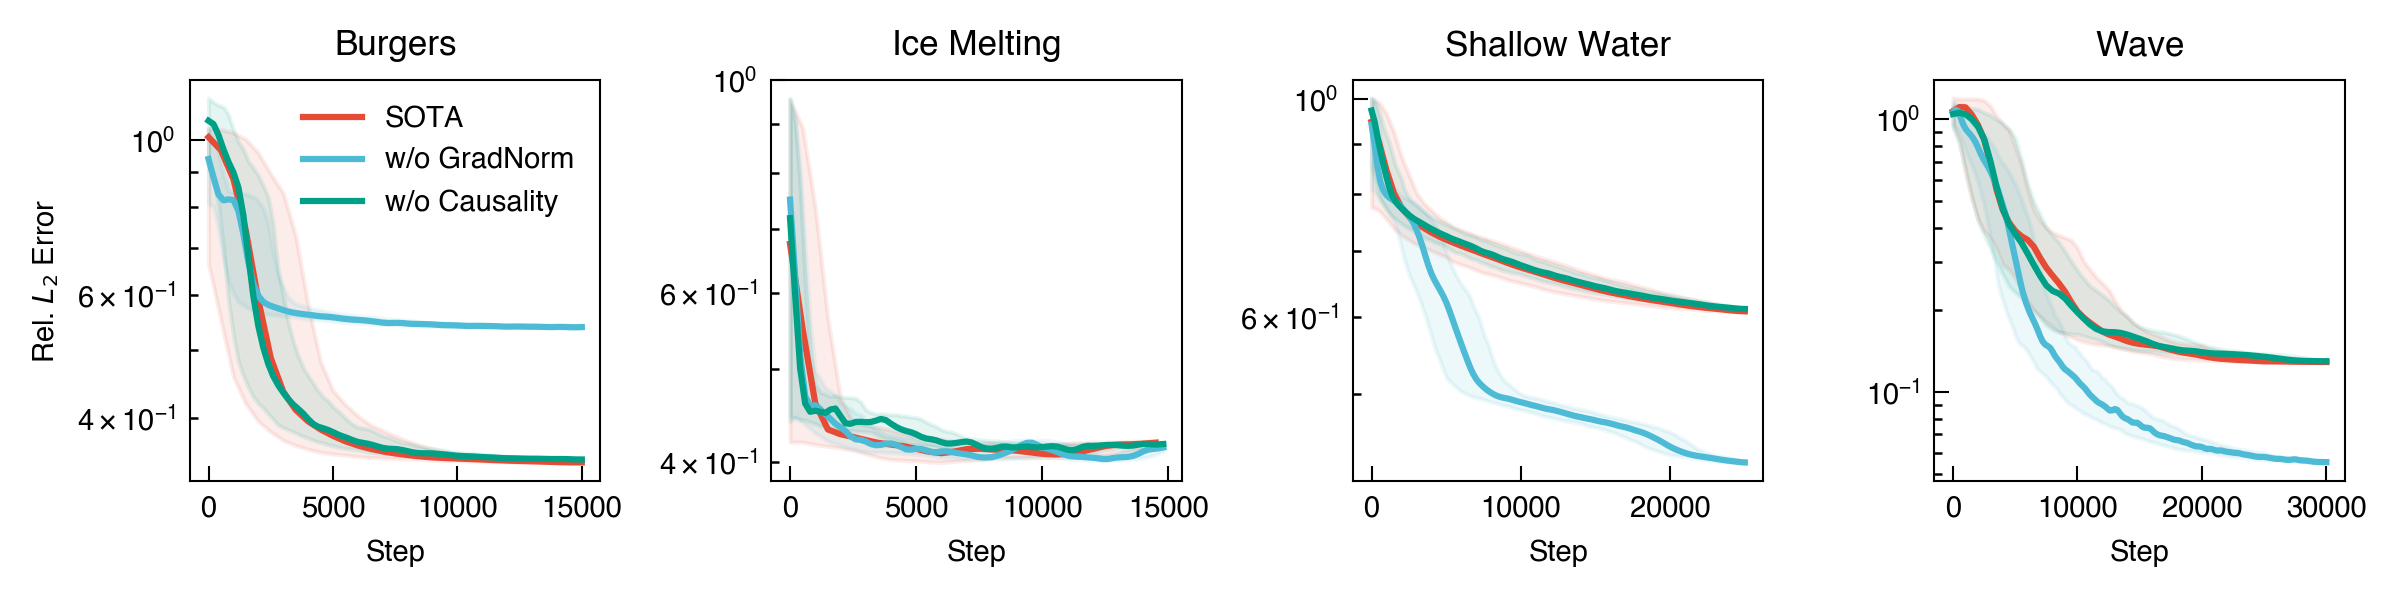

In [6]:
deeponet_ret = {
    "Burgers": [
        "training_logs/burgers/run-burgers_deeponet_baseline-0219-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_deeponet_ablation_no_gradnorm_20260320-165712-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_deeponet_ablation_no_causality_20260320-225700-tag-eval_l2_error.csv"
    ],
    "Ice Melting": [
        "training_logs/ice_melting/run-ice_melting_ellipse_deeponet_typical-tag-eval_l2_error.csv",
        "training_logs/ice_melting/run-ice_melting_ellipse_deeponet_ablation_no_gradnom-tag-eval_l2_error.csv",
        "training_logs/ice_melting/run-ice_melting_ellipse_deeponet_ablation_no_causal-tag-eval_l2_error.csv"
    ],
    "Shallow Water": [
        "training_logs/swe/run-swe_deeponet_baseline-tag-eval_l2_error.csv",
        "training_logs/swe/run-swe_deeponet_no_gradnorm_20260320-165723-tag-eval_l2_error.csv",
        "training_logs/swe/run-swe_deeponet_no_causality_20260320-232107-tag-eval_l2_error.csv"
    ],
    "Wave": [
        "training_logs/wave/run-wave_deeponet_baseline-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_deeponet_ablation_no_gradnorm_20260320-192922-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_deeponet_ablation_no_causality_20260323-161922-tag-eval_l2_error.csv"
    ]
}

tags = ["SOTA", "w/o GradNorm", "w/o Causality"]
model_name = "CViT"
max_steps = [15000, 15000, 25000, 30000]


from models.utils import smooth_loss_log_gaussian
fig, axes = plt.subplots(1, 4, figsize=(8, 2),)

for example_idx, (name, paths) in enumerate(deeponet_ret.items()):
    ax = axes[example_idx]
    
    if example_idx == 0:
        ax.set_ylabel(f"Rel. $L_2$ Error")
    ax.set_title(name)
    ax.set_xlabel("Step")
        
    if len(paths) == 0:
        continue
        
    for j, (path, tag) in enumerate(zip(paths, tags)):
        df = pd.read_csv(path)
        df = df[df["Step"] <= max_steps[example_idx]]
        val = df["Value"].values
        step = df["Step"].values
        mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.2, n_boot=1000)
        ax.fill_between(step, lower, upper, color=f"C{j}", alpha=0.1,)
        ax.plot(step, mean, label=tag, color=f"C{j}")
    ax.set_yscale("log")
    
    if example_idx == 0:
        ax.legend()
fig.tight_layout()


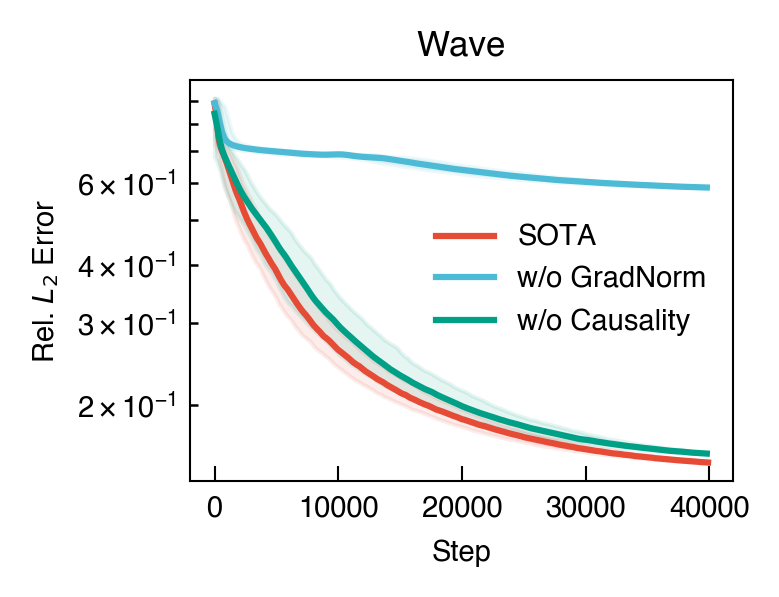

In [7]:
fno_ret = {
    "Wave": [
        "training_logs/wave/run-wave_fno_soap-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_fno_no_gradnorm_20260321-081100-tag-eval_l2_error.csv",
        "training_logs/wave/run-wave_fno_no_causal_20260321-121240-tag-eval_l2_error.csv"
    ]
}

tags = ["SOTA", "w/o GradNorm", "w/o Causality"]
model_name = "CViT"
max_steps = [40000]


from models.utils import smooth_loss_log_gaussian
fig, ax = plt.subplots(1, 1, figsize=(2.6, 2),)

for example_idx, (name, paths) in enumerate(fno_ret.items()):
    
    if example_idx == 0:
        ax.set_ylabel(f"Rel. $L_2$ Error")
    ax.set_title(name)
    ax.set_xlabel("Step")
        
    if len(paths) == 0:
        continue
        
    for j, (path, tag) in enumerate(zip(paths, tags)):
        df = pd.read_csv(path)
        df = df[df["Step"] <= max_steps[example_idx]]
        val = df["Value"].values
        step = df["Step"].values
        mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.2, n_boot=1000)
        ax.fill_between(step, lower, upper, color=f"C{j}", alpha=0.1,)
        ax.plot(step, mean, label=tag, color=f"C{j}")
    ax.set_yscale("log")
    
    if example_idx == 0:
        ax.legend()
fig.tight_layout()


## Ablation: Num of training data

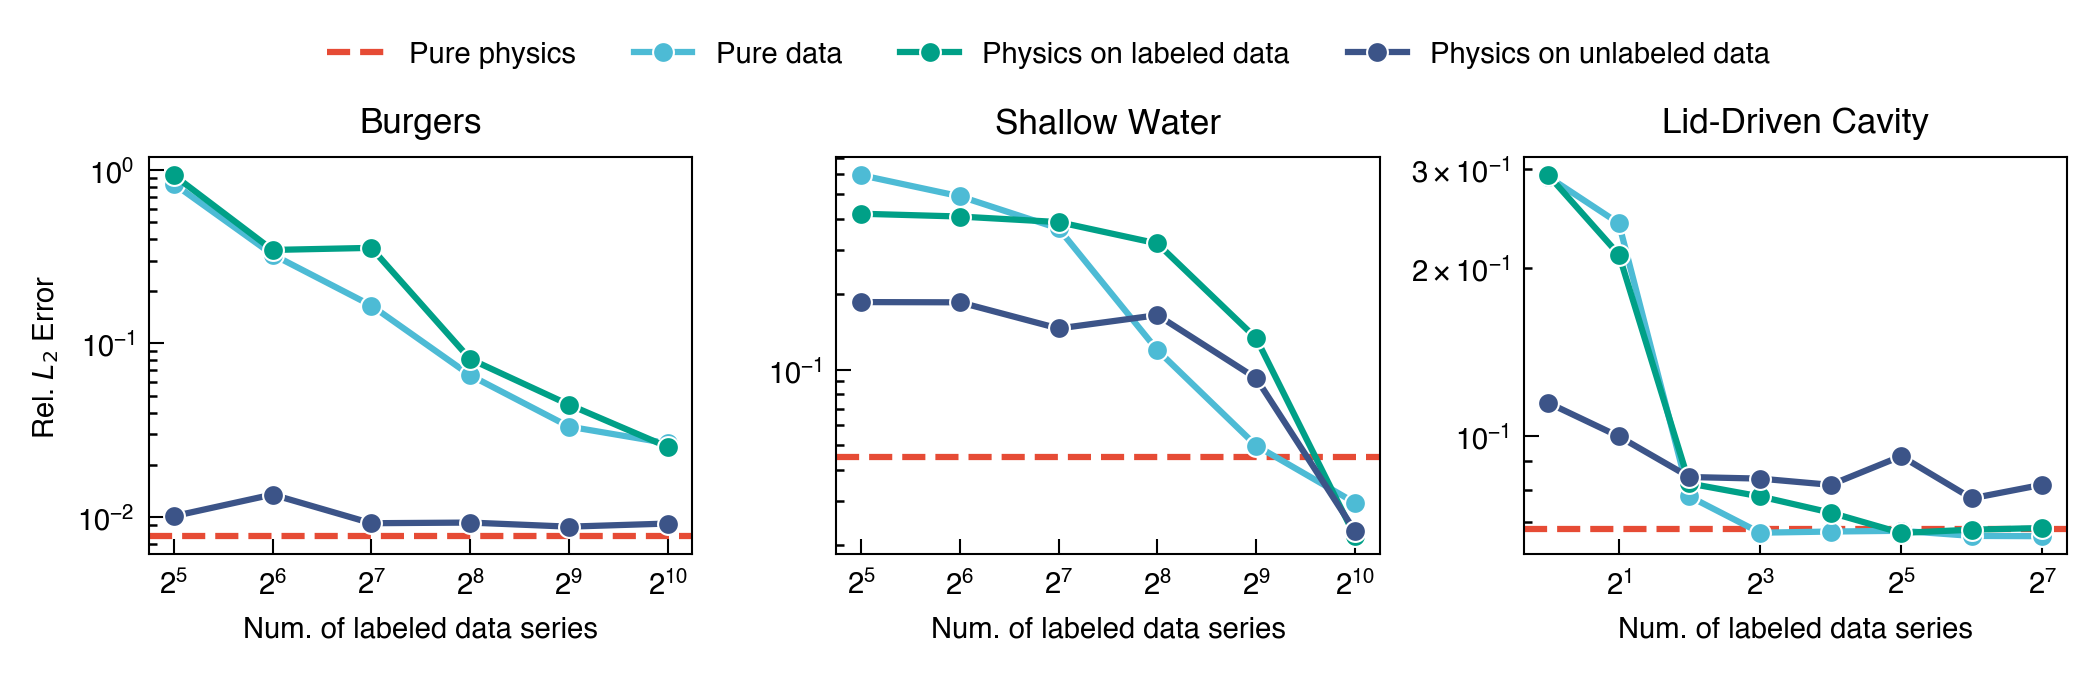

In [12]:
datasets = {
    "Burgers" : "./training_logs/burgers/data_vs_physics.txt",
    "Shallow Water" : "./training_logs/swe/data_vs_physics.txt",
    "Lid-Driven Cavity" : "./training_logs/ldc/data_vs_physics.txt",
}
pure_physics_err = [7.744e-3, 4.50e-2, 6.8e-2]

fig, axes = plt.subplots(1, 3, figsize=(7, 2),)
axes = axes.flatten()

for idx, (name, path) in enumerate(datasets.items()):

    ax = axes[idx]
    ax.set_title(name)
    ax.set_yscale("log")
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Num. of labeled data series")
    if idx==0:
        ax.set_ylabel("Rel. $L_2$ Error")
    
    
    ax.axhline(pure_physics_err[idx], color="C0", 
               label="Pure physics"if idx == 1 else None,
               ls="--")
        
    if path is None:
        continue
     
    df = pd.read_csv(path, sep=",")

    xs = df["num_labeled_data_seriers"].values
    ax.plot(xs, df["pure_data"]/100, 
            marker="o", label="Pure data" if idx == 1 else None,
            color="C1",
            markersize=5, markeredgecolor="white", markeredgewidth=0.5)
    ax.plot(xs, df["physics_on_data"]/100, 
            marker="o", label="Physics on labeled data" if idx == 1 else None,
            color="C2", 
            markersize=5, markeredgecolor="white", markeredgewidth=0.5)
    ax.plot(xs, df["hybrid_physics_data"]/100, 
            marker="o", label="Physics on unlabeled data" if idx == 1 else None,
            color="C3",
            markersize=5, markeredgecolor="white", markeredgewidth=0.5)
    
fig.legend(loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.1))
fig.tight_layout()

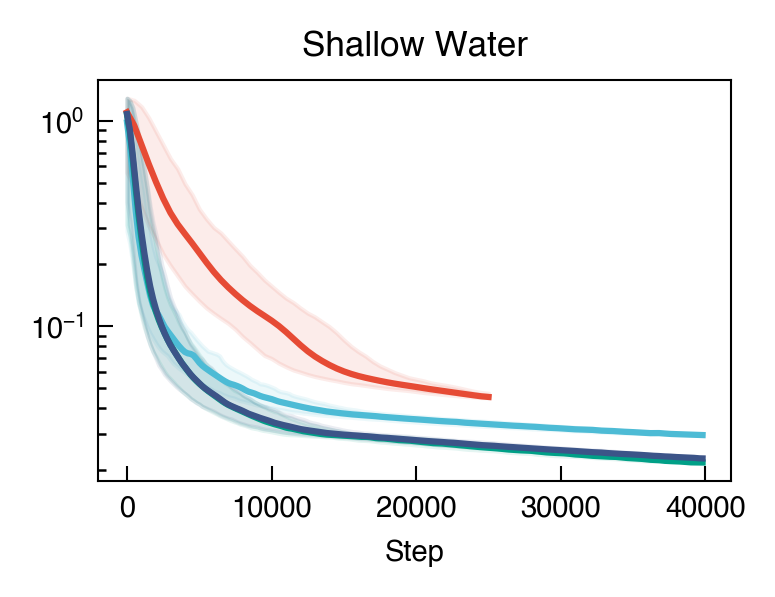

In [ ]:
paths = [
    "training_logs/swe/run-swe_cvit_SOTA-0217-tag-eval_l2_error.csv",
    "training_logs/swe/run-logs_swe_cvit_pure_data_dataset_size_1024-tag-eval_l2_error.csv",
    "training_logs/swe/run-logs_swe_cvit_physics_on_labeled_data_dataset_size_1024-tag-eval_l2_error.csv",
    "training_logs/swe/run-logs_swe_cvit_physics_on_unlabeled_data_dataset_size_1024-tag-eval_l2_error.csv",
]
tags = [
    "Pure physics",
    "Pure data",
    "Physics on labeled data",
    "Physics on unlabeled data"
]
fig, ax = plt.subplots(1, 1, figsize=(2.6, 2),)
for path, tag in zip(paths, tags):
    df = pd.read_csv(path)
    val = df["Value"].values
    step = df["Step"].values
    mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.2, n_boot=1000)
    ax.fill_between(step, lower, upper, color=f"C{tags.index(tag)}", alpha=0.1,)
    ax.plot(step, mean, label=tag, color=f"C{tags.index(tag)}")
ax.set(xlabel="Step", title="Shallow Water",
       yscale="log")
fig.tight_layout()

## Ablation: Derivative scheme---Finite difference vs. automatic differentiation

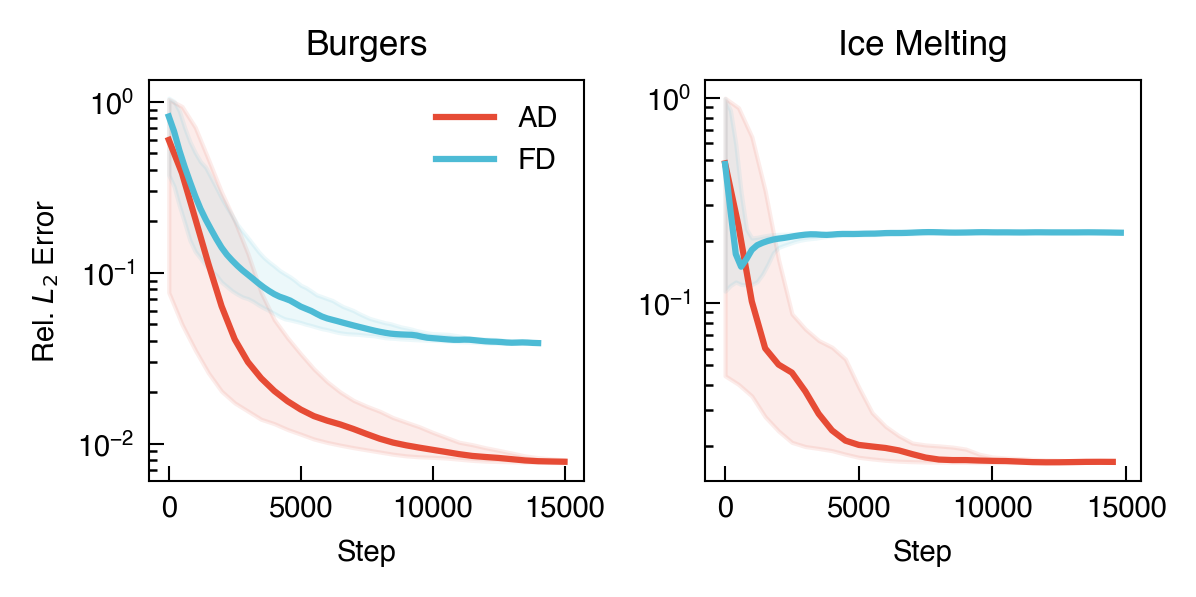

In [ ]:
datasets = {
    "Burgers": [
        "training_logs/burgers/run-burgers_cvit_sota-nofilm-tag-eval_l2_error.csv",
        "training_logs/burgers/run-burgers_cvit_ablation_loss_fd-tag-eval_l2_error.csv",
    ],
    "Ice Melting": [
        "training_logs/ice_melting/run-ice_melting_ellipse_cvit_sota-0121-tag-eval_l2_error.csv",
        "training_logs/ice_melting/run-ice_melting_ellipse_cvit_ablation_loss_fd-tag-eval_l2_error.csv"
    ],
}

tags = ["AD", "FD"]

fig, axes = plt.subplots(1, 2, figsize=(4, 2),)
axes = axes.flatten()
for idx, (name, paths) in enumerate(datasets.items()):
    ax = axes[idx]
    for j, (path, tag) in enumerate(zip(paths, tags)):
        if path is None:
            continue
        df = pd.read_csv(path)
        val = df["Value"].values
        step = df["Step"].values
        mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1.2, n_boot=1000)
        ax.fill_between(step, lower, upper, color=f"C{j}", alpha=0.1,)
        ax.plot(step, mean, label=tag, color=f"C{j}")

    ax.set(xlabel="Step", title=name,
           yscale="log")
    if idx == 0:
        ax.legend()
        ax.set(ylabel="Rel. $L_2$ Error")
        
fig.tight_layout()
